# Data Preprocessing

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from collections import Counter
from pyexpat import features
from scipy import stats

# extra imports
from pandas import read_csv
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn import preprocessing
from pandas.plotting import scatter_matrix
from scipy.stats import boxcox
from statsmodels.genmod.generalized_linear_model import GLM

## LOADING THE DATA

In [18]:
wifi = pd.read_csv('../data/raw/train_nt.csv', header=0, delimiter=';')
wifi.shape

(12888, 262)

The dataset has 12888 samples and 262 attributes 

In [19]:
wifi.head()

,ID,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,...,Q59_2,I60_2,Q60_2,I61_2,Q61_2,I62_2,Q62_2,I63_2,Q63_2,position
0,0,0,-5703,-88,-88,0,0,4,5,7,...,-13,6,-13,-2,-8,3,-12,1,-12,9
1,1,0,1835,-91,-88,0,0,-10,4,-7,...,-7,-11,-9,-18,-7,-8,-8,-8,-10,9
2,2,0,4,-86,-87,0,0,5,14,5,...,10,7,16,7,13,11,16,11,13,9
3,3,52464,1259,-81,-71,0,0,-1,12,1,...,13,-7,14,-6,17,-6,16,-7,16,2
4,4,0,900,-82,-76,0,0,9,2,9,...,6,14,4,16,7,14,7,14,2,2


## BASIC INSPECTION OF THE DATASET

In [20]:
wifi.describe()

,ID,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,...,Q59_2,I60_2,Q60_2,I61_2,Q61_2,I62_2,Q62_2,I63_2,Q63_2,position
count,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.0,12888.0,12888.000000,12888.000000,12888.000000,...,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000
mean,6443.500000,16008.409683,15.017070,-78.052297,-77.951505,0.0,0.0,-0.406425,-0.477576,-0.499690,...,-0.401691,-0.354826,-0.295624,-0.328057,-0.294693,-0.311065,-0.269165,-0.240534,-0.362663,4.493094
std,3720.589469,19829.509485,3087.311342,6.804665,8.349372,0.0,0.0,10.208896,10.122726,10.415635,...,10.549412,10.406506,10.520399,11.013205,11.159978,11.075438,11.248325,11.017986,11.117985,2.871060
min,0.000000,0.000000,-8703.000000,-97.000000,-94.000000,0.0,0.0,-25.000000,-26.000000,-24.000000,...,-25.000000,-25.000000,-26.000000,-32.000000,-38.000000,-25.000000,-26.000000,-27.000000,-31.000000,0.000000
25%,3221.750000,0.000000,-1751.000000,-83.000000,-84.000000,0.0,0.0,-10.000000,-10.000000,-10.000000,...,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-11.000000,-11.000000,-10.000000,-11.000000,2.000000
50%,6443.500000,5464.000000,-30.000000,-80.000000,-80.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
75%,9665.250000,29424.000000,1798.000000,-74.000000,-71.000000,0.0,0.0,9.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,7.000000
max,12887.000000,65520.000000,8915.000000,-58.000000,-58.000000,0.0,0.0,25.000000,25.000000,23.000000,...,23.000000,29.000000,23.000000,33.000000,35.000000,25.000000,25.000000,26.000000,26.000000,9.000000


Notice no missing values at first.

1) Which is the target variable, and where is it? The target variable is the last column and is called "position".

2) How many different values does the target variable have? 10 possible values (0-9)

3) Is it a classification problem or a regression problem? Classification problem.

## DEALING WITH MISSING VALUES

In [21]:
number_of_missing_values = wifi.isnull().sum()
print(number_of_missing_values)
print('Total missing values on the dataset:', number_of_missing_values.sum())

ID          0
seq_ctrl    0
aoa         0
rssi1       0
rssi2       0
           ..
I62_2       0
Q62_2       0
I63_2       0
Q63_2       0
position    0
Length: 262, dtype: int64
Total missing values on the dataset: 0


No values explicitly marked as missing.

array([[<Axes: title={'center': 'seq_ctrl'}>,
        <Axes: title={'center': 'aoa'}>],
       [<Axes: title={'center': 'rssi1'}>,
        <Axes: title={'center': 'rssi2'}>],
       [<Axes: title={'center': 'position'}>, <Axes: >]], dtype=object)

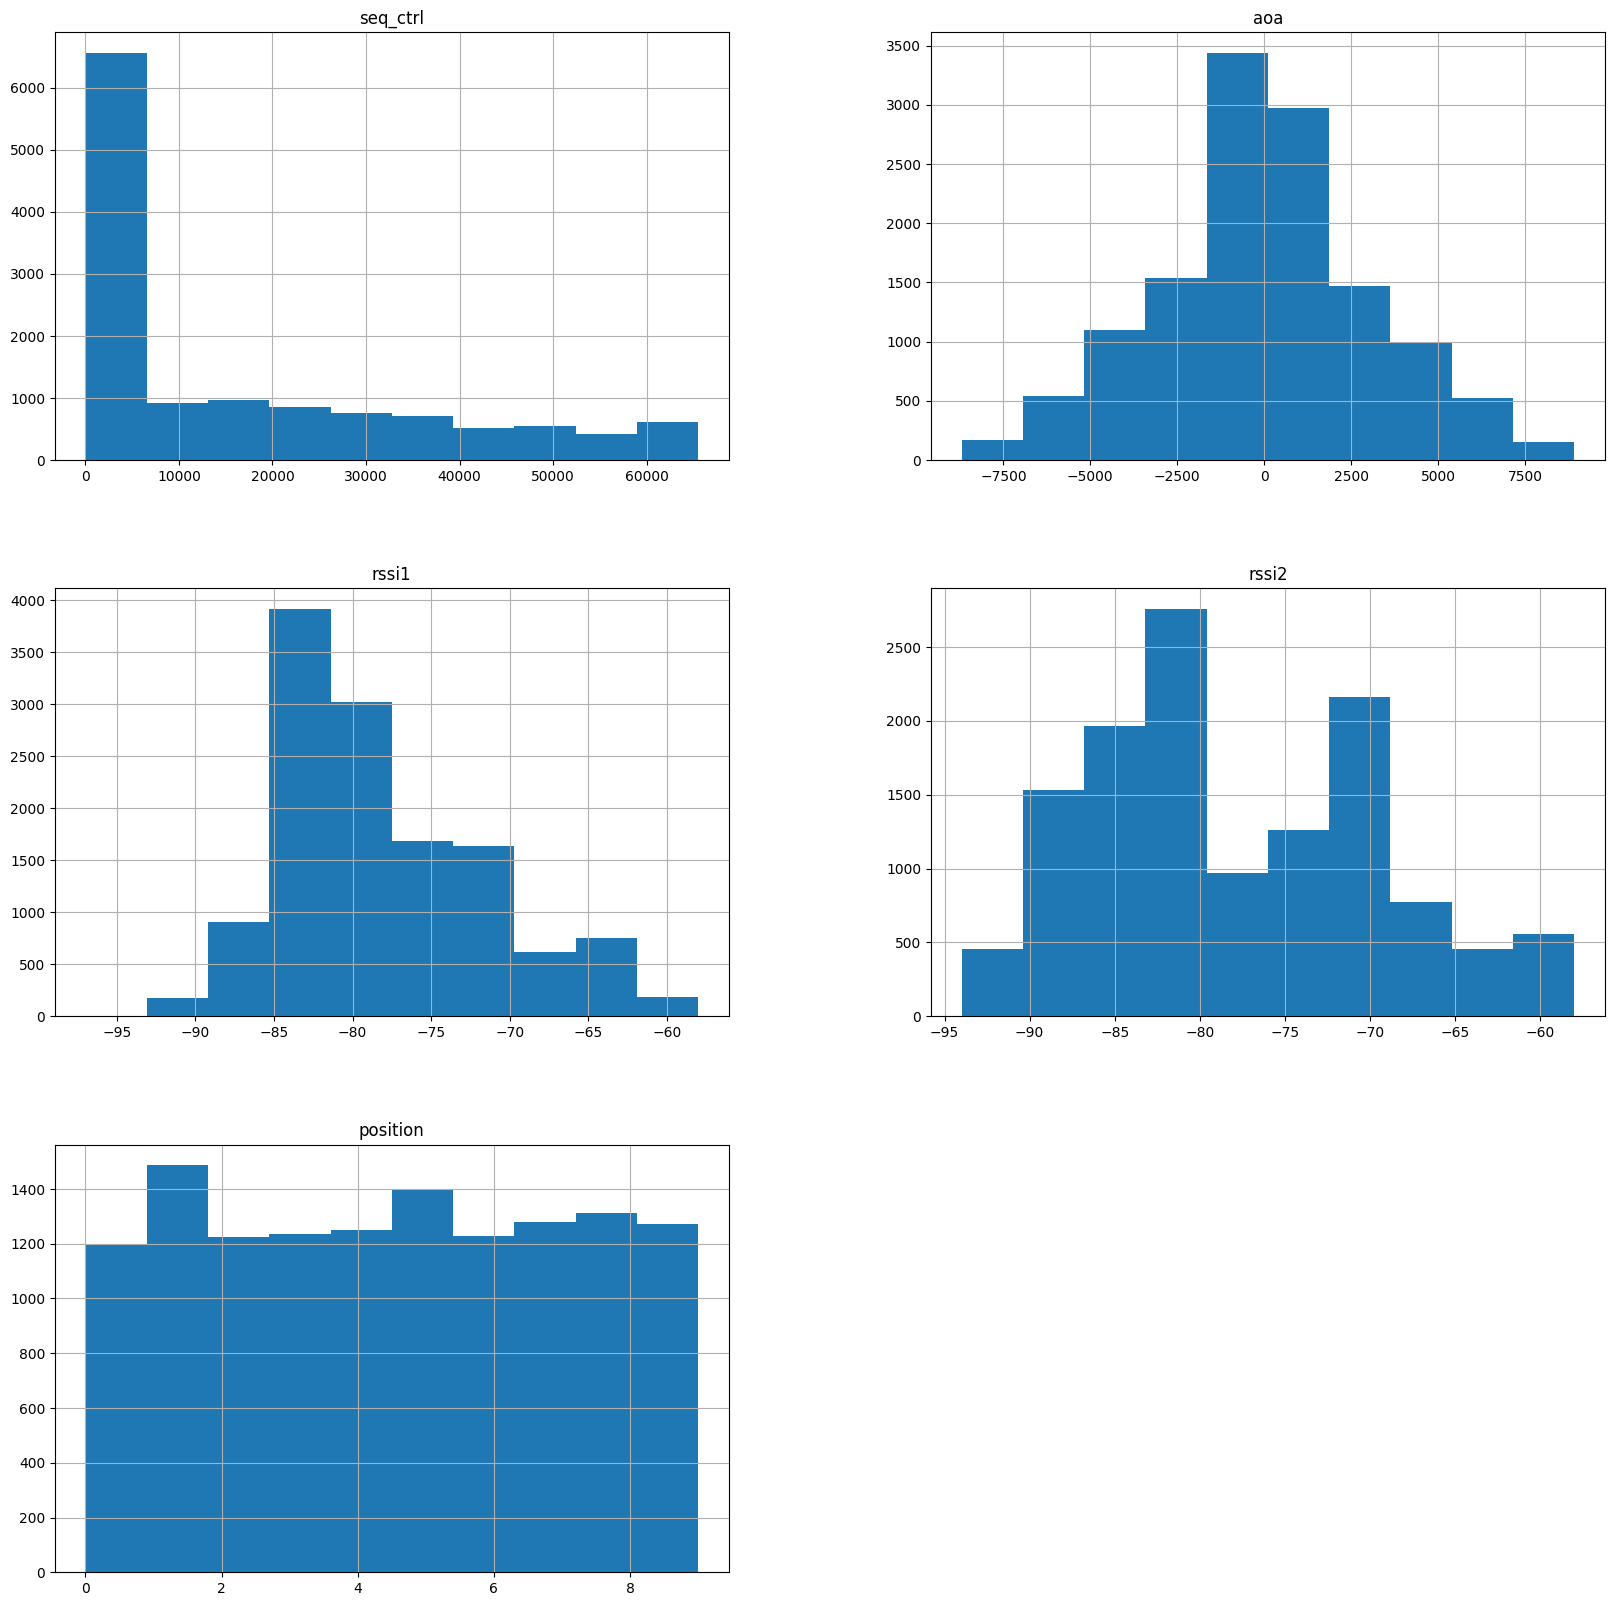

In [22]:
wifi_non_raw_csi = wifi[['seq_ctrl', 'aoa', 'rssi1', 'rssi2', 'position']]
wifi_non_raw_csi.hist(figsize=(20,20))

In [23]:
wifi_non_raw_csi.describe()

,seq_ctrl,aoa,rssi1,rssi2,position
count,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000
mean,16008.409683,15.017070,-78.052297,-77.951505,4.493094
std,19829.509485,3087.311342,6.804665,8.349372,2.871060
min,0.000000,-8703.000000,-97.000000,-94.000000,0.000000
25%,0.000000,-1751.000000,-83.000000,-84.000000,2.000000
50%,5464.000000,-30.000000,-80.000000,-80.000000,5.000000
75%,29424.000000,1798.000000,-74.000000,-71.000000,7.000000
max,65520.000000,8915.000000,-58.000000,-58.000000,9.000000


There are no strange values that could be considered as missing values or outliers.


## FINDING OUTLIERS

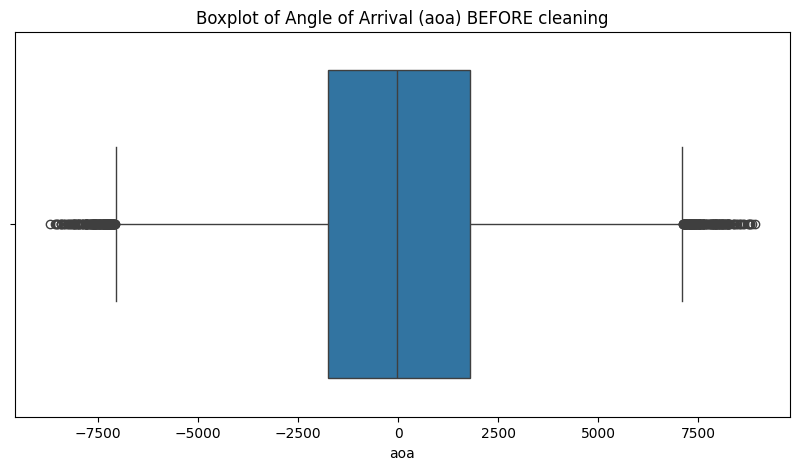

Realistic outliers in AOA: 303


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Plot the raw data first so you can see the outliers with your own eyes
plt.figure(figsize=(10, 5))
sns.boxplot(x=wifi['aoa'])
plt.title("Boxplot of Angle of Arrival (aoa) BEFORE cleaning")
plt.show()

# 2. Use simple IQR to find realistic outliers (e.g., people walking in front of the antenna)
Q1 = wifi['aoa'].quantile(0.25)
Q3 = wifi['aoa'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Count how many REAL outliers there are (It should be a few hundred, NOT 12,000!)
outliers = wifi[(wifi['aoa'] < lower_bound) | (wifi['aoa'] > upper_bound)]
print(f"Realistic outliers in AOA: {len(outliers)}")


### IQR

In [25]:
for column in wifi_non_raw_csi.columns:
    print(f"Column: {column}")

    Q1 = wifi[column].quantile(0.25)
    Q3 = wifi[column].quantile(0.75)
    IQR = Q3 - Q1

    Q1, Q3, IQR
    (np.float64(1116.25), np.float64(1691.5), np.float64(575.25))
    small_outliers = wifi[column] < (Q1 - 1.5 * IQR)
    big_outliers = wifi[column] > (Q3 + 1.5 * IQR)

    print(f"There are {sum(small_outliers)} 'small' outliers and {sum(big_outliers)} 'big' outliers.")

Column: seq_ctrl
There are 0 'small' outliers and 0 'big' outliers.
Column: aoa
There are 146 'small' outliers and 157 'big' outliers.
Column: rssi1
There are 1 'small' outliers and 48 'big' outliers.
Column: rssi2
There are 0 'small' outliers and 0 'big' outliers.
Column: position
There are 0 'small' outliers and 0 'big' outliers.


### Model based

In [26]:
for column in wifi_non_raw_csi.columns:
    print(f"Column: {column}")
    local_outlier_factor = LocalOutlierFactor(n_neighbors=50)
    result = local_outlier_factor.fit_predict(wifi[column].values.reshape(-1, 1))

    outliers = result == -1
    no_outliers = result == 1
    print(f"Outliers in {column}: {Counter(result)[1]}")


Column: seq_ctrl


C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Outliers in seq_ctrl: 12865
Column: aoa
Outliers in aoa: 12738
Column: rssi1
Outliers in rssi1: 12829
Column: rssi2
Outliers in rssi2: 12832
Column: position
Outliers in position: 12888


C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


### TREATMENT OF MIXED DATA TYPES

All variables are numerical, so we don't have to worry about mixed data types.

## DERIVATION OF NEW VARIABLES - FEATURE EXTRACTION

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

def extract_iq_pairs(df):
    """Extract I/Q pairs from raw CSI columns (antenna 1 and 2)."""
    # 64 subcarriers per antenna
    I1_cols = [f'I{n}_1' for n in range(64)]
    Q1_cols = [f'Q{n}_1' for n in range(64)]
    I2_cols = [f'I{n}_2' for n in range(64)]
    Q2_cols = [f'Q{n}_2' for n in range(64)]
    
    IQ_ant1 = df[I1_cols].values + 1j * df[Q1_cols].values
    IQ_ant2 = df[I2_cols].values + 1j * df[Q2_cols].values
    return IQ_ant1, IQ_ant2

def compute_amplitude(IQ): return np.abs(IQ)
def compute_phase(IQ): return np.angle(IQ)
def compute_phase_unwrapped(phase): return np.unwrap(phase, axis=1)

def sanitize_phase(phase_unwr):
    """Remove linear SFO (Sampling Frequency Offset) trend from unwrapped phase."""
    x = np.arange(phase_unwr.shape[1])
    sanitized = np.zeros_like(phase_unwr)
    for i in range(phase_unwr.shape[0]):
        m, c = np.polyfit(x, phase_unwr[i], 1)
        sanitized[i] = phase_unwr[i] - (m * x + c)
    return sanitized

def compute_frequency_domain_features(data):
    """Treats the 64 subcarriers as a 'signal' to find Channel Impulse Response (CIR) features."""
    fft_result = np.fft.fft(data, axis=1)
    fft_mag = np.abs(fft_result)
    
    features = {}
    features['spectral_energy'] = np.sum(fft_mag ** 2, axis=1)
    
    # Add epsilon to prevent log(0) crash in entropy calculation
    safe_fft_mag = fft_mag + 1e-10 
    features['spectral_entropy'] = stats.entropy(safe_fft_mag, axis=1)
    
    bins = np.arange(fft_mag.shape[1])
    features['spectral_centroid'] = np.sum(fft_mag * bins, axis=1) / np.sum(safe_fft_mag, axis=1)
    return features

def compute_antenna_correlation(IQ_ant1, IQ_ant2):
    correlations = []
    for i in range(len(IQ_ant1)):
        # Calculate correlation between the amplitude of Ant1 and Ant2
        corr = np.corrcoef(np.abs(IQ_ant1[i]), np.abs(IQ_ant2[i]))[0, 1]
        correlations.append(corr)
    # np.nan_to_num catches any division-by-zero NaNs caused by flat signals
    return np.nan_to_num(correlations, nan=0.0)

def compute_phase_consistency(phase_ant1, phase_ant2):
    """Mean Resultant Length of the phase difference (measures spatial coherence)."""
    phase_diff = np.angle(np.exp(1j * (phase_ant1 - phase_ant2)))
    cos_mean = np.mean(np.cos(phase_diff), axis=1)
    sin_mean = np.mean(np.sin(phase_d   iff), axis=1)
    return np.sqrt(cos_mean ** 2 + sin_mean ** 2)

def extract_all_features(df):
    IQ_ant1, IQ_ant2 = extract_iq_pairs(df)
    features = {}    

    # 1. Amplitude & Phase Base Metrics
    amp_ant1 = compute_amplitude(IQ_ant1)
    amp_ant2 = compute_amplitude(IQ_ant2)
    phase_ant1 = compute_phase(IQ_ant1)
    phase_ant2 = compute_phase(IQ_ant2)
    
    # 2. Phase Sanitization (The Golden Feature)
    phase_unwr_ant1 = compute_phase_unwrapped(phase_ant1)
    phase_unwr_ant2 = compute_phase_unwrapped(phase_ant2)
    sanitized_p1 = sanitize_phase(phase_unwr_ant1)
    sanitized_p2 = sanitize_phase(phase_unwr_ant2)
    rel_phase = sanitized_p1 - sanitized_p2

    # 3. Frequency Domain Features
    for k, v in compute_frequency_domain_features(amp_ant1).items(): 
        features[f'freq_ant1_{k}'] = v
    for k, v in compute_frequency_domain_features(amp_ant2).items(): 
        features[f'freq_ant2_{k}'] = v
    
    # 4. Cross-Antenna Features
    features['antenna_correlation'] = compute_antenna_correlation(IQ_ant1, IQ_ant2)
    features['phase_consistency'] = compute_phase_consistency(phase_ant1, phase_ant2)
    
    # 5. Amplitude Statistics
    features['amp_ant1_mean'] = np.mean(amp_ant1, axis=1)
    features['amp_ant1_std'] = np.std(amp_ant1, axis=1)
    features['amp_ant2_mean'] = np.mean(amp_ant2, axis=1)
    features['amp_ant2_std'] = np.std(amp_ant2, axis=1)
    
    # 6. Relative Phase Statistics
    features['rel_phase_mean'] = np.mean(rel_phase, axis=1)
    features['rel_phase_std'] = np.std(rel_phase, axis=1)
    
    # 7. Safe AoA Encoding
    # Assuming hardware scale where 8915 = 89.15 degrees
    aoa_rad = np.deg2rad(df['aoa'].values / 100.0)
    features['aoa_sin'] = np.sin(aoa_rad)
    features['aoa_cos'] = np.cos(aoa_rad)
    
    features['rssi1'] = df['rssi1'].values
    features['rssi2'] = df['rssi2'].values
    
    # 8. Build Final DataFrame
    df_features = pd.DataFrame(features) 
    return df_features

# Execute
wifi_features = extract_all_features(wifi)
print(f"Extracted {wifi_features.shape[1]} features successfully.")

Extracted 18 features successfully.


In [28]:
wifi_features = extract_all_features(wifi)
print(f"Extracted {wifi_features.shape[1]-1} features successfully.")
wifi_features.head()

Extracted 17 features successfully.


,freq_ant1_spectral_energy,freq_ant1_spectral_entropy,freq_ant1_spectral_centroid,freq_ant2_spectral_energy,freq_ant2_spectral_entropy,freq_ant2_spectral_centroid,antenna_correlation,phase_consistency,amp_ant1_mean,amp_ant1_std,amp_ant2_mean,amp_ant2_std,rel_phase_mean,rel_phase_std,aoa_sin,aoa_cos,rssi1,rssi2
0,622912.0,3.293113,23.923196,551104.0,3.220061,23.990110,0.457565,0.209775,10.500734,6.466274,9.595087,6.517759,-2.671474e-16,1.230063,-0.838956,0.544200,-88,-88
1,687616.0,3.506048,24.893213,424768.0,3.339236,24.835525,0.397510,0.678378,11.039852,6.782084,8.080124,6.197960,-1.380840e-15,2.020773,0.314821,0.949151,-91,-88
2,524544.0,3.431066,24.533911,545728.0,3.397970,24.216590,0.766544,0.916925,9.683494,5.855974,9.918375,5.904254,1.162265e-16,0.385168,0.000698,1.000000,-86,-87
3,634496.0,3.288601,24.905849,712064.0,3.242197,23.492324,0.100826,0.645218,9.683126,7.819419,11.229586,6.909425,1.561251e-16,0.902391,0.217973,0.975955,-81,-71
4,524672.0,3.355711,25.304652,509568.0,3.253057,23.216126,0.468697,0.682586,8.693792,7.246498,9.798835,5.328141,1.318390e-16,1.091202,0.156434,0.987688,-82,-76


In [29]:
wifi_features.describe()

,freq_ant1_spectral_energy,freq_ant1_spectral_entropy,freq_ant1_spectral_centroid,freq_ant2_spectral_energy,freq_ant2_spectral_entropy,freq_ant2_spectral_centroid,antenna_correlation,phase_consistency,amp_ant1_mean,amp_ant1_std,amp_ant2_mean,amp_ant2_std,rel_phase_mean,rel_phase_std,aoa_sin,aoa_cos,rssi1,rssi2
count,1.288800e+04,12888.000000,12888.000000,1.288800e+04,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,1.288800e+04,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000
mean,6.031116e+05,3.263817,23.744095,5.921104e+05,3.302459,23.777349,0.752104,0.703543,10.301629,6.309942,10.293085,6.114690,3.450742e-19,1.038509,0.001254,0.864986,-78.052297,-77.951505
std,7.386938e+04,0.087279,0.724854,8.676549e+04,0.121302,0.939139,0.191359,0.197347,0.825414,0.789873,0.922406,0.608618,5.520785e-16,0.548482,0.467105,0.183386,6.804665,8.349372
min,5.907200e+04,2.948853,22.383519,9.369600e+04,3.042533,22.330213,-0.262451,0.011759,3.074768,2.228829,3.667012,3.070508,-4.496403e-15,0.048882,-0.998657,0.014835,-97.000000,-94.000000
25%,5.586560e+05,3.203939,23.093495,5.452000e+05,3.217094,23.049528,0.658564,0.594510,9.768812,5.705844,9.841451,5.714561,-2.116363e-16,0.610295,-0.300872,0.800234,-83.000000,-84.000000
50%,6.033920e+05,3.249042,23.702082,5.956480e+05,3.256008,23.460847,0.779056,0.712493,10.359086,6.116301,10.415830,6.026254,-1.734723e-18,1.027405,-0.005236,0.952555,-80.000000,-80.000000
75%,6.512640e+05,3.306873,24.278966,6.464640e+05,3.362220,24.240644,0.901709,0.865869,10.888689,6.842962,10.905638,6.415624,2.118531e-16,1.394412,0.308685,0.987688,-74.000000,-71.000000
max,1.026688e+06,3.722932,27.287473,1.251328e+06,3.777846,26.969244,0.996632,0.998675,13.175883,9.445326,14.299543,10.186853,3.788636e-15,5.015873,0.999890,1.000000,-58.000000,-58.000000


Note that `freq_ant1_dominant_freq_bin` and `freq_ant2_dominant_freq_bin` are 0.0 for all samples. Therefore, these features do not provide any useful information for classification and can be removed from the dataset without losing any info.

In [30]:
wifi = pd.concat([wifi, wifi_features], axis=1)

In [31]:
print(wifi.shape)
wifi.head()
wifi.describe()

(12888, 280)


,ID,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,...,amp_ant1_mean,amp_ant1_std,amp_ant2_mean,amp_ant2_std,rel_phase_mean,rel_phase_std,aoa_sin,aoa_cos,rssi1,rssi2
count,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.0,12888.0,12888.000000,12888.000000,12888.000000,...,12888.000000,12888.000000,12888.000000,12888.000000,1.288800e+04,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000
mean,6443.500000,16008.409683,15.017070,-78.052297,-77.951505,0.0,0.0,-0.406425,-0.477576,-0.499690,...,10.301629,6.309942,10.293085,6.114690,3.450742e-19,1.038509,0.001254,0.864986,-78.052297,-77.951505
std,3720.589469,19829.509485,3087.311342,6.804665,8.349372,0.0,0.0,10.208896,10.122726,10.415635,...,0.825414,0.789873,0.922406,0.608618,5.520785e-16,0.548482,0.467105,0.183386,6.804665,8.349372
min,0.000000,0.000000,-8703.000000,-97.000000,-94.000000,0.0,0.0,-25.000000,-26.000000,-24.000000,...,3.074768,2.228829,3.667012,3.070508,-4.496403e-15,0.048882,-0.998657,0.014835,-97.000000,-94.000000
25%,3221.750000,0.000000,-1751.000000,-83.000000,-84.000000,0.0,0.0,-10.000000,-10.000000,-10.000000,...,9.768812,5.705844,9.841451,5.714561,-2.116363e-16,0.610295,-0.300872,0.800234,-83.000000,-84.000000
50%,6443.500000,5464.000000,-30.000000,-80.000000,-80.000000,0.0,0.0,0.000000,0.000000,0.000000,...,10.359086,6.116301,10.415830,6.026254,-1.734723e-18,1.027405,-0.005236,0.952555,-80.000000,-80.000000
75%,9665.250000,29424.000000,1798.000000,-74.000000,-71.000000,0.0,0.0,9.000000,9.000000,9.000000,...,10.888689,6.842962,10.905638,6.415624,2.118531e-16,1.394412,0.308685,0.987688,-74.000000,-71.000000
max,12887.000000,65520.000000,8915.000000,-58.000000,-58.000000,0.0,0.0,25.000000,25.000000,23.000000,...,13.175883,9.445326,14.299543,10.186853,3.788636e-15,5.015873,0.999890,1.000000,-58.000000,-58.000000


We delete all columns were all values are 0.0 (do not app)

In [16]:
const_col = [col for col in wifi.columns if wifi[col].nunique() <= 1]

print(f"Columnas eliminadas: {const_col}")
wifi.drop(columns=const_col, inplace=True)
print(wifi.shape)

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

Let's plot the features:

Generating 19 histograms. This may take a moment...


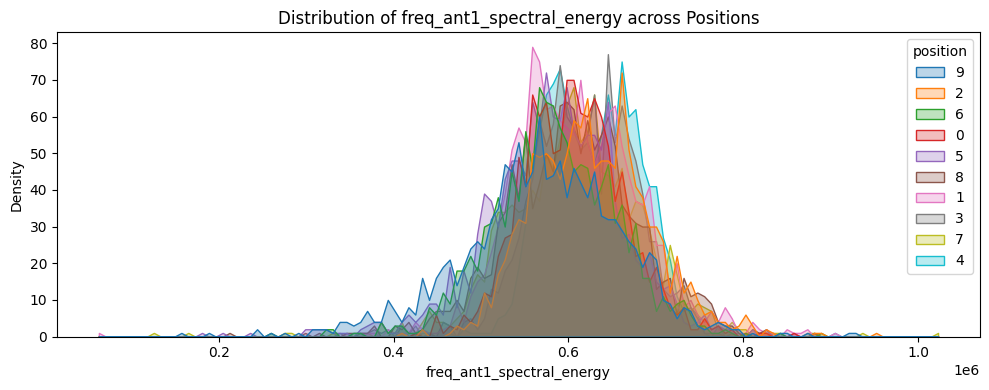

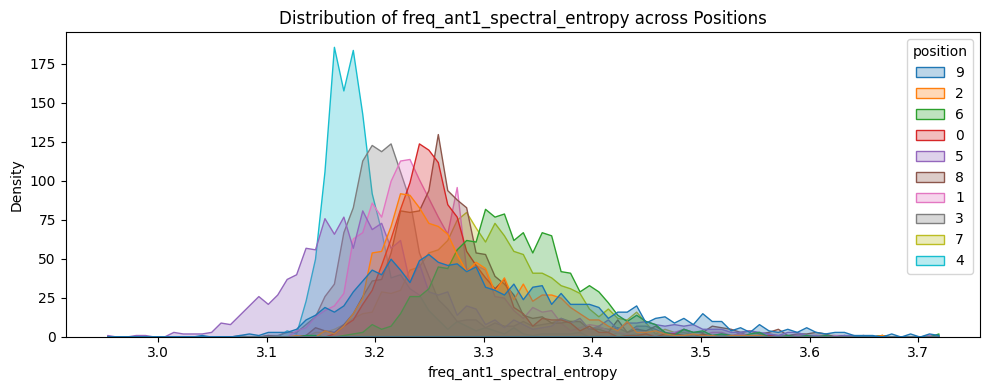

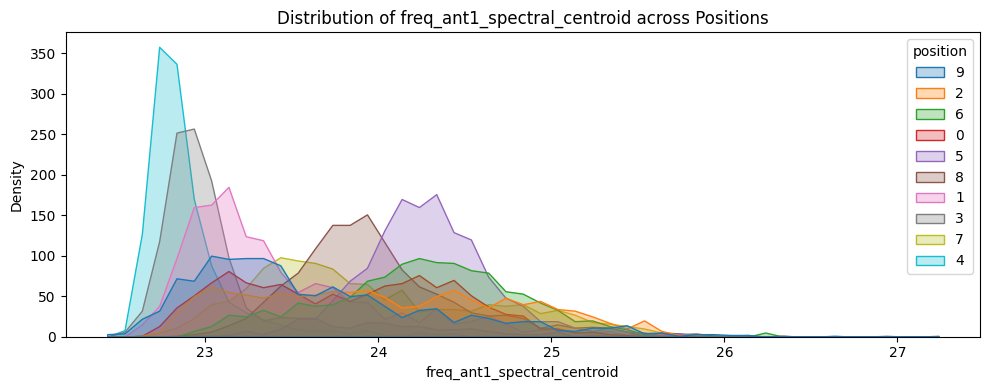

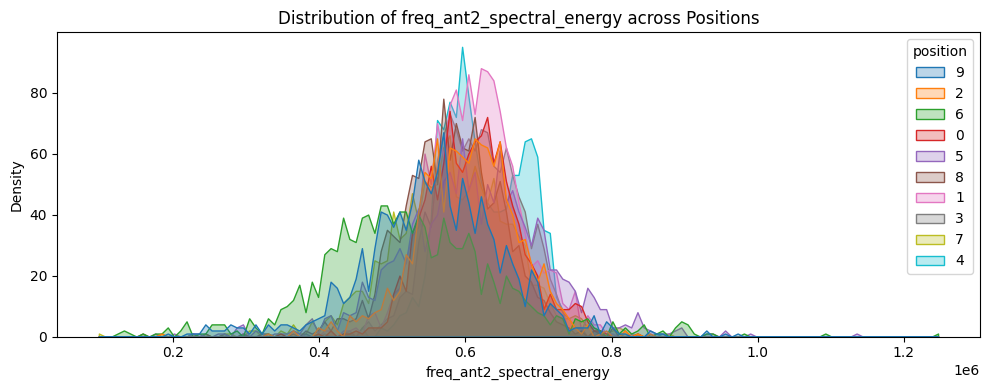

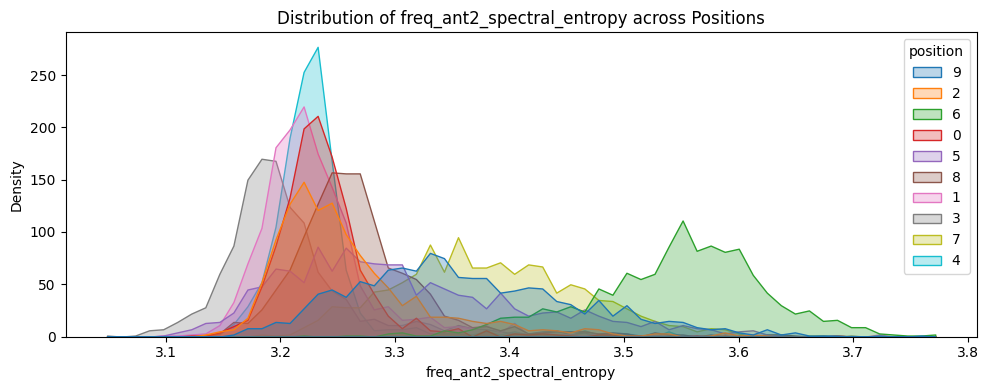

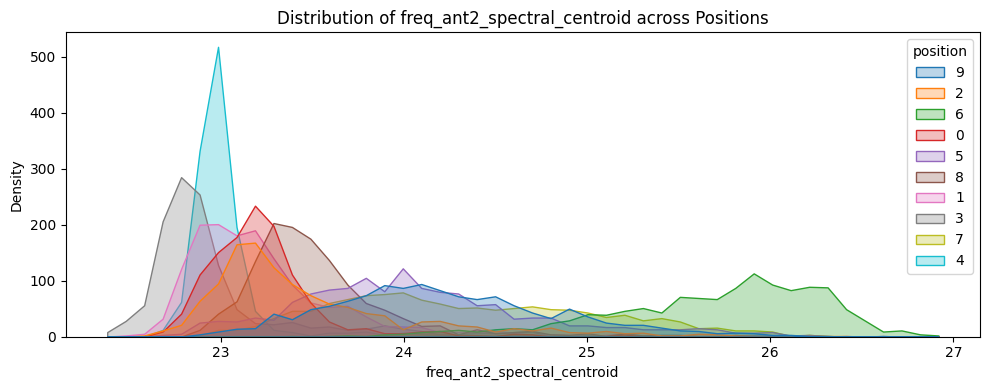

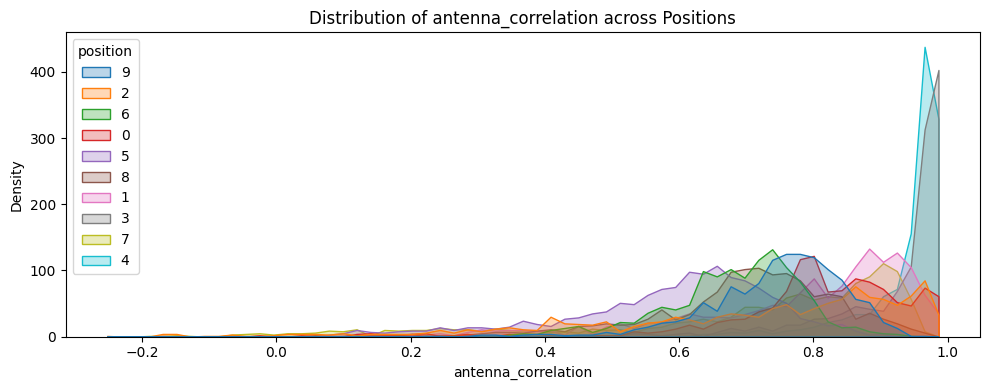

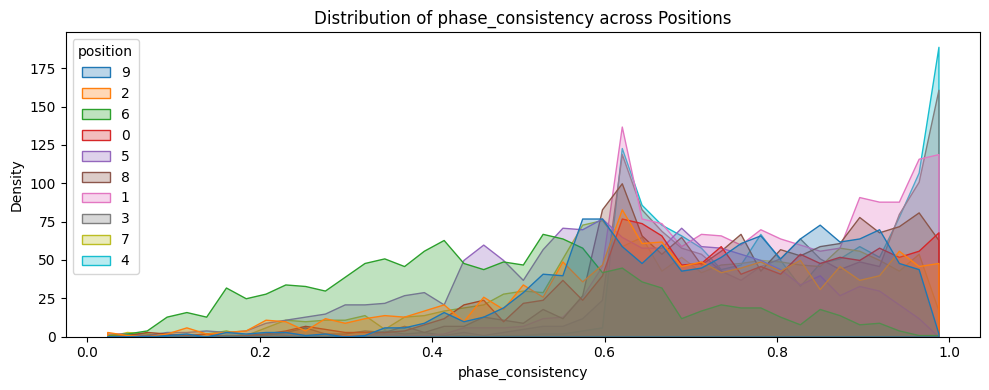

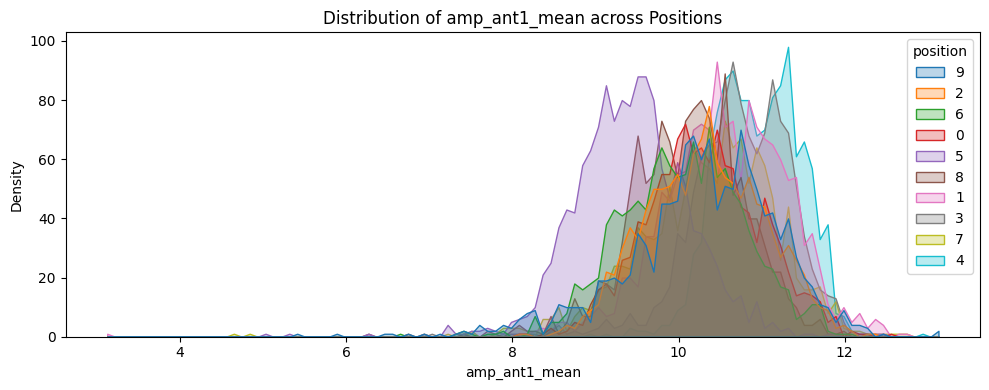

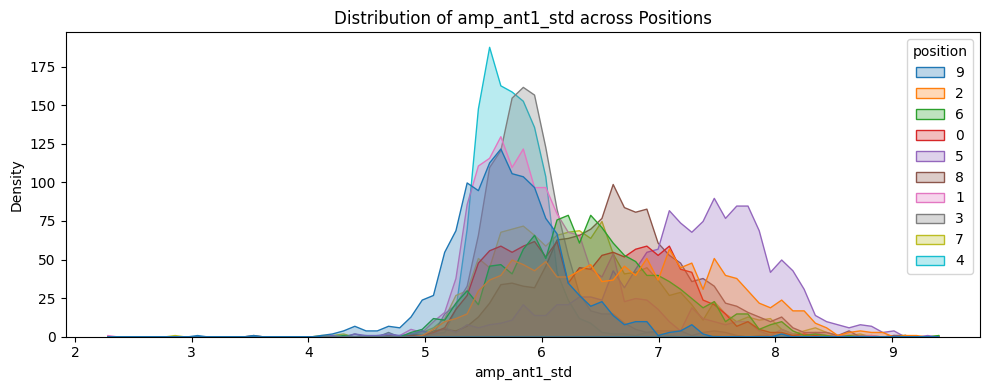

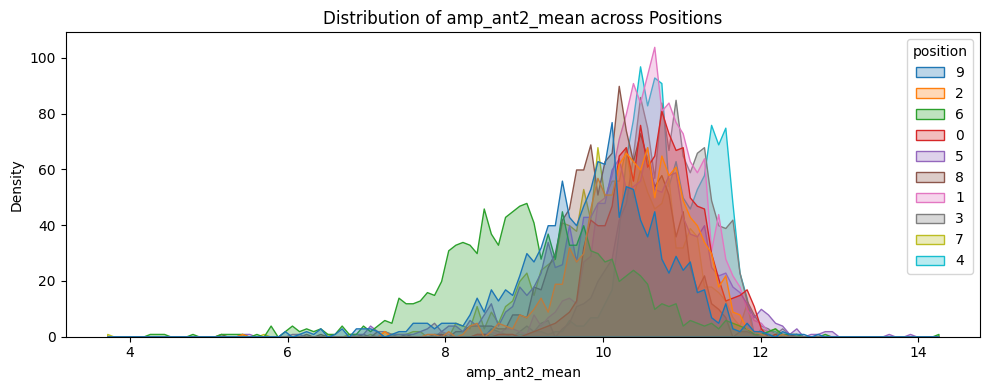

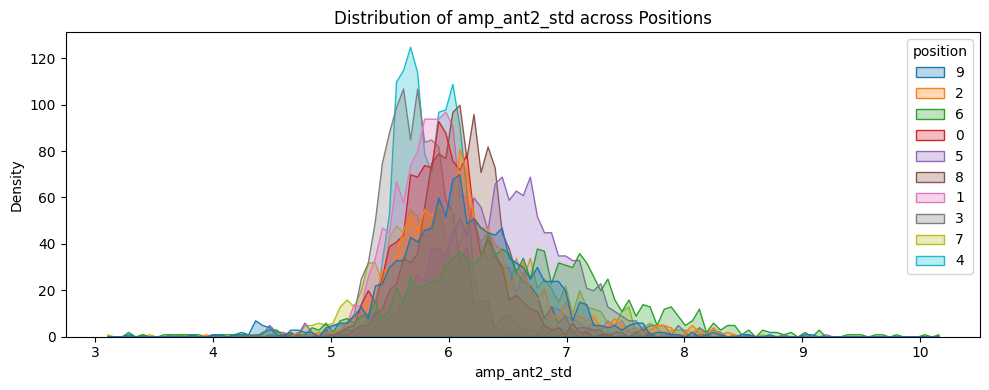

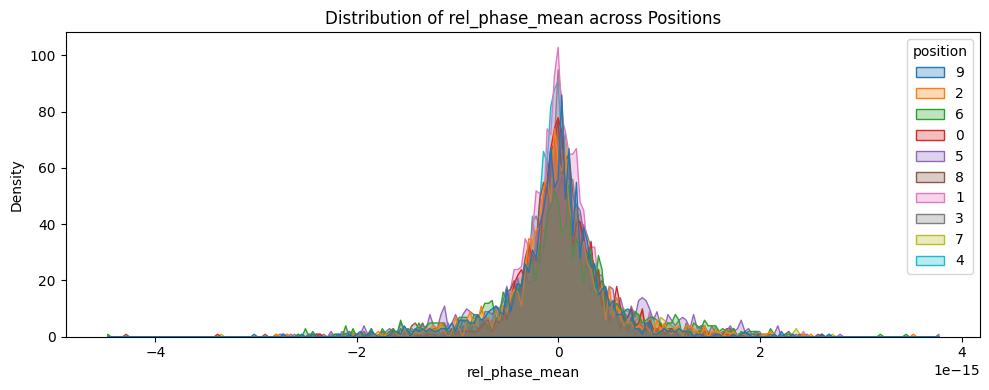

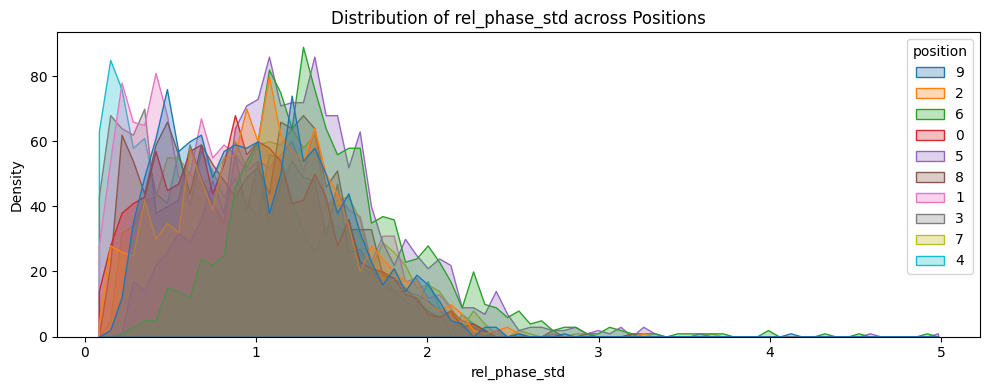

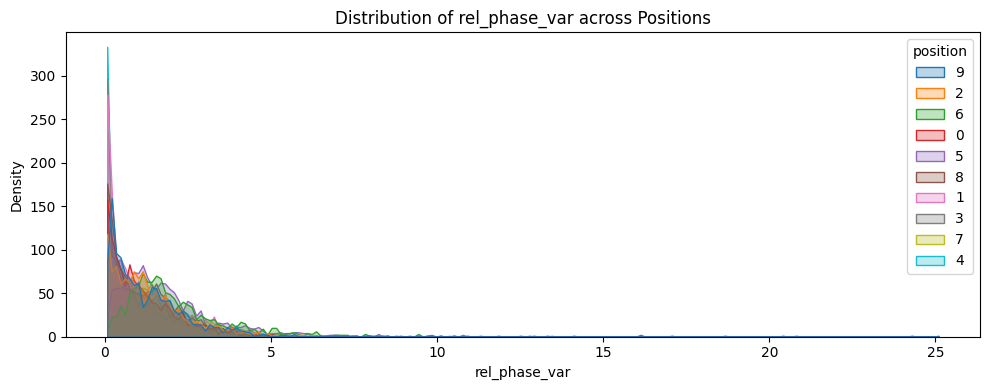

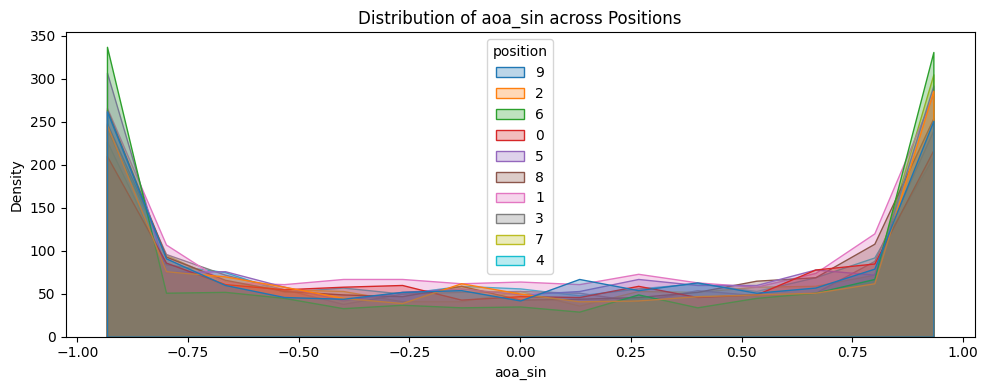

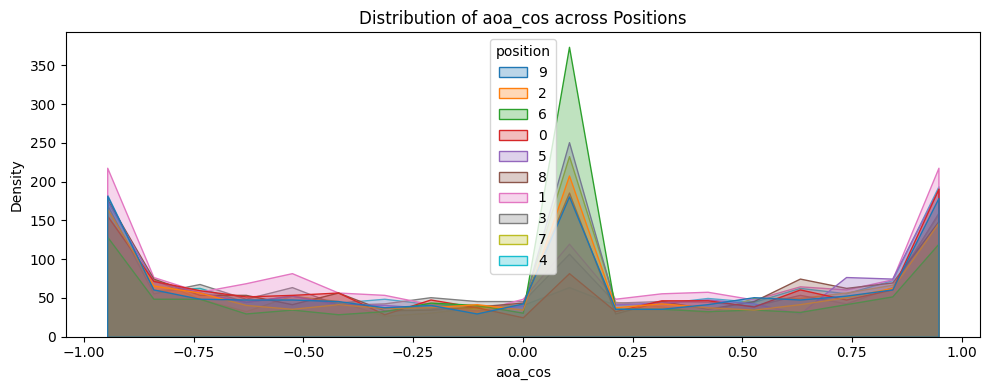

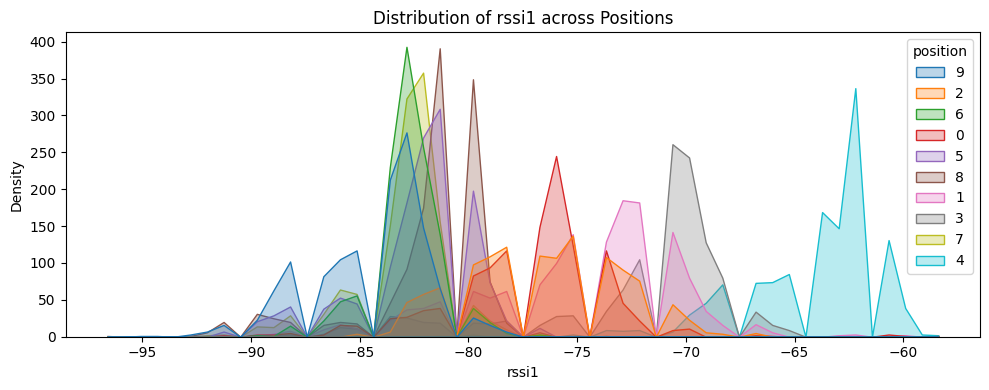

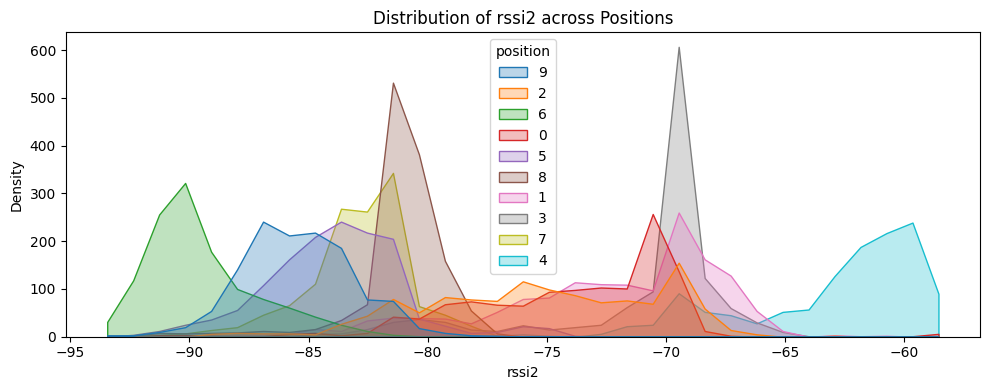

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure position is treated as a categorical variable for coloring
wifi['position'] = wifi['position'].astype(str)

features_to_plot = [col for col in wifi.columns if col != 'position']

print(f"Generating {len(features_to_plot)} histograms. This may take a moment...")

for feature in features_to_plot:
    plt.figure(figsize=(10, 4))
    
    # Using element='poly' or 'step' makes overlapping distributions easier to see than bars
    sns.histplot(
        data=wifi, 
        x=feature, 
        hue='position', 
        palette='tab10', 
        element='poly', 
        common_norm=False, 
        alpha=0.3
    )
    
    plt.title(f"Distribution of {feature} across Positions")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

# Revert position to int for ML modeling
wifi['position'] = wifi['position'].astype(int)

BEST FEATURES (SEPARATE THE MOST): rssi1 and rssi2.

**Should we remove outliers?**
*No.* In this data, extreme RSSI or AoA values represent specific physical edge-cases (e.g., multipath fading, a person standing directly in front of the antenna). If we delete these rows, our model cannot learn how to handle those scenarios in production.

**The Solution:**
Instead of deleting rows, we use model-specific preprocessing. We pass the data through standard scalers, robust scalers, or PCA depending entirely on what the target Machine Learning algorithm mathematically assumes.

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Setup Paths and Split Data
PROCESSED_DATA_PATH = '../data/processed/'
os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

X = wifi_features.drop(columns=['position'])
y = wifi_features['position']

# Split BEFORE any transformations to prevent data leakage
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. List of models we are exporting customized data for
target_models = [
    'lda', 'qda', 'knn', 'svm', 'logistic', 
    'xgboost', 'lightgbm', 'mlp', 'cnn', 'lstm'
]

print("Starting explicit data transformations and CSV exports...\n")

for model in target_models:
    print(f"[{model.upper()}] Processing...")
    
    # Start with a fresh copy of the raw data for each model
    X_train_proc = X_train_raw.copy()
    X_val_proc = X_val_raw.copy()
    
    # --- APPLY TRANSFORMATIONS ---
    
    if model in ['lda', 'logistic']:
        # Standardize, then remove noisy features
        scaler = StandardScaler()
        X_train_proc = scaler.fit_transform(X_train_proc)
        X_val_proc = scaler.transform(X_val_proc)
        
        #selector = SelectKBest(f_classif, k=60)
        X_train_proc = selector.fit_transform(X_train_proc, y_train)
        X_val_proc = selector.transform(X_val_proc)
        
    elif model == 'qda':
        # Standardize, then orthogonalize to prevent collinearity crashes
        scaler = StandardScaler()
        X_train_proc = scaler.fit_transform(X_train_proc)
        X_val_proc = scaler.transform(X_val_proc)
        
        X_train_proc = pca.fit_transform(X_train_proc)
        X_val_proc = pca.transform(X_val_proc)
        
    elif model == 'knn':
        # Bound distances, then compact space
        scaler = MinMaxScaler()
        X_train_proc = scaler.fit_transform(X_train_proc)
        X_val_proc = scaler.transform(X_val_proc)
        
        X_train_proc = pca.fit_transform(X_train_proc)
        X_val_proc = pca.transform(X_val_proc)
        
    elif model == 'svm':
        # Zero-center, then compact space for RBF kernel speed
        scaler = StandardScaler()
        X_train_proc = scaler.fit_transform(X_train_proc)
        X_val_proc = scaler.transform(X_val_proc)
        
        X_train_proc = pca.fit_transform(X_train_proc)
        X_val_proc = pca.transform(X_val_proc)
        
    elif model == 'mlp':
        # Handle outliers with RobustScaler for stable gradients
        scaler = RobustScaler()
        X_train_proc = scaler.fit_transform(X_train_proc)
        X_val_proc = scaler.transform(X_val_proc)
        
        X_train_proc = pca.fit_transform(X_train_proc)
        X_val_proc = pca.transform(X_val_proc)
        
    elif model in ['cnn', 'lstm']:
        # Zero-center for gradients, but DO NOT reduce dimensions (preserve spatial array)
        scaler = StandardScaler()
        X_train_proc = scaler.fit_transform(X_train_proc)
        X_val_proc = scaler.transform(X_val_proc)
        
    elif model in ['xgboost', 'lightgbm', 'random_forest']:
        # Trees need raw data. No scaling or reduction applied.
        pass
    
    # --- CONVERT TO DATAFRAMES AND SAVE ---
    
    # If the array was transformed into numpy, generate generic column names
    if isinstance(X_train_proc, np.ndarray):
        if X_train_proc.shape[1] == X_train_raw.shape[1]:
            cols = X_train_raw.columns # Structure preserved
        else:
            cols = [f'feature_{i}' for i in range(X_train_proc.shape[1])] # PCA or KBest changed column count
    else:
        cols = X_train_proc.columns
        
    df_train = pd.DataFrame(X_train_proc, columns=cols)
    df_train['position'] = y_train.values
    
    df_val = pd.DataFrame(X_val_proc, columns=cols)
    df_val['position'] = y_val.values
    
    train_file = os.path.join(PROCESSED_DATA_PATH, f'Xtrain_{model}.csv')
    val_file = os.path.join(PROCESSED_DATA_PATH, f'Xval_{model}.csv')
    
    df_train.to_csv(train_file, index=False)
    df_val.to_csv(val_file, index=False)
    
    print(f"  -> Saved {train_file} ({df_train.shape[1]-1} features)")

print("\n✅ All personalized CSVs exported successfully!")

Starting explicit data transformations and CSV exports...

[LDA] Processing...


C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=60 is greater than n_features=19. All the features will be returned.
  warnings.warn(


  -> Saved ../data/processed/Xtrain_lda.csv (19 features)
[QDA] Processing...


ValueError: n_components=40 must be between 0 and min(n_samples, n_features)=19 with svd_solver='covariance_eigh'